<a href="https://colab.research.google.com/github/aarushimendiratta2201-ui/Food-Insecurity-ML-model/blob/main/Food_Insecurity_Final_Project.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
#importing the needed modules
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.metrics import accuracy_score
import plotly.express as px
from sklearn.preprocessing import LabelEncoder

import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (confusion_matrix, classification_report,
                            accuracy_score, precision_score, recall_score,
                            f1_score, roc_auc_score)
from sklearn.preprocessing import StandardScaler
from imblearn.over_sampling import SMOTE  # For handling class imbalance

In [ ]:
pfrom google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
#reading the first file
roar = pd.read_csv('/content/drive/MyDrive/food_insecurity.csv')
#cleaning the data
df = roar.dropna(axis=1, how='all')
food_insecurity = df.melt(id_vars=['Country Name','Country Code', 'Indicator Name', 'Indicator Code'], var_name='year', value_name='Food Insecurity Percentage')
food_insecurity.sort_values(by = ['Country Name', 'year'], inplace = True)


##reading and cleaning the second data file
poverty = pd.read_csv('/content/drive/MyDrive/poverty_data.csv')
poverty.rename(columns={'country': 'Country Name'}, inplace=True)
poverty['year'] = poverty['year'].astype(str)
poverty

,Country Name,year,reporting_level,welfare_type,ppp_version,survey_year,survey_comparability,headcount_ratio_international_povline,headcount_ratio_lower_mid_income_povline,headcount_ratio_upper_mid_income_povline,...,decile8_thr,decile9_thr,gini,mld,polarization,palma_ratio,s80_s20_ratio,p90_p10_ratio,p90_p50_ratio,p50_p10_ratio
0,Albania,1996,national,consumption,2011,1996.0,0.0,0.920669,11.174149,44.618417,...,8.85,10.92,0.270103,0.119104,0.241293,0.928335,3.945872,3.568627,1.889273,1.888889
1,Albania,2002,national,consumption,2011,2002.0,1.0,1.570843,14.132118,49.669635,...,8.83,11.58,0.317390,0.164812,0.268982,1.215056,4.831625,3.979381,2.090253,1.903780
2,Albania,2005,national,consumption,2011,2005.0,1.0,0.860527,8.715685,38.545254,...,10.02,12.78,0.305957,0.154413,0.254529,1.142718,4.662236,3.872727,1.978328,1.957576
3,Albania,2008,national,consumption,2011,2008.0,1.0,0.313650,5.250542,31.110345,...,10.74,13.62,0.299847,0.148893,0.247311,1.114657,4.395911,3.574803,1.956897,1.826772
4,Albania,2012,national,consumption,2011,2012.0,1.0,0.849754,6.182414,34.528906,...,10.52,13.26,0.289605,0.138417,0.249988,1.041193,4.272573,3.632877,1.941435,1.871233
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4872,Zambia,2010,national,consumption,2017,2010.0,4.0,68.456606,82.885088,93.044964,...,3.27,5.34,0.556215,0.539135,0.536149,4.278696,16.024650,10.470588,3.955556,2.647059
4873,Zambia,2015,national,consumption,2017,2015.0,4.0,61.352160,77.548045,90.747141,...,4.02,6.43,0.571361,0.604667,0.613181,4.995829,21.243915,13.978261,4.095541,3.413043
4874,Zimbabwe,2011,national,consumption,2017,2011.0,0.0,21.580063,47.857143,77.945113,...,7.25,10.54,0.431536,0.311153,0.388356,2.207938,8.526847,6.713376,2.773684,2.420382
4875,Zimbabwe,2017,national,consumption,2017,2017.0,0.0,34.206046,61.583570,84.109019,...,5.96,8.81,0.443371,0.322848,0.416694,2.307359,8.569542,6.574627,3.069686,2.141791


In [ ]:
##concatenating our two dataframes
merged_df = pd.merge(food_insecurity, poverty, on=['Country Name', 'year'])
merged_df.rename(columns={'year': 'Years'}, inplace=True)
merged_df.dropna(subset=['Food Insecurity Percentage'], inplace=True)
merged_df

,Country Name,Country Code,Indicator Name,Indicator Code,Years,Food Insecurity Percentage,reporting_level,welfare_type,ppp_version,survey_year,...,decile8_thr,decile9_thr,gini,mld,polarization,palma_ratio,s80_s20_ratio,p90_p10_ratio,p90_p50_ratio,p50_p10_ratio
0,Albania,ALB,Prevalence of severe food insecurity in the po...,SN.ITK.SVFI.ZS,2015,10.0,national,consumption,2011,2015.00,...,13.80,18.26,0.327537,0.175495,0.300364,1.248506,5.278241,4.599496,2.229548,2.062972
1,Albania,ALB,Prevalence of severe food insecurity in the po...,SN.ITK.SVFI.ZS,2015,10.0,national,consumption,2017,2015.00,...,16.66,22.06,0.327537,0.175495,0.300364,1.248506,5.278241,4.595833,2.230536,2.060417
2,Albania,ALB,Prevalence of severe food insecurity in the po...,SN.ITK.SVFI.ZS,2016,10.5,national,consumption,2011,2016.00,...,14.78,19.18,0.337363,0.187581,0.314380,1.306972,5.626880,4.930591,2.251174,2.190231
3,Albania,ALB,Prevalence of severe food insecurity in the po...,SN.ITK.SVFI.ZS,2016,10.5,national,income,2011,2016.00,...,11.88,16.02,0.385656,0.273740,0.350360,1.696002,8.286575,6.965217,2.376855,2.930435
4,Albania,ALB,Prevalence of severe food insecurity in the po...,SN.ITK.SVFI.ZS,2016,10.5,national,consumption,2017,2016.00,...,17.86,23.16,0.337363,0.187581,0.314380,1.306972,5.626880,4.927660,2.252918,2.187234
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
857,Vanuatu,VUT,Prevalence of severe food insecurity in the po...,SN.ITK.SVFI.ZS,2019,2.4,national,consumption,2017,2019.21,...,7.31,9.36,0.323176,0.176084,0.277515,1.242286,5.281881,4.353488,2.004283,2.172093
870,Zimbabwe,ZWE,Prevalence of severe food insecurity in the po...,SN.ITK.SVFI.ZS,2017,35.9,national,consumption,2011,2017.00,...,5.30,7.83,0.443371,0.322848,0.416694,2.307359,8.569542,6.579832,3.070588,2.142857
871,Zimbabwe,ZWE,Prevalence of severe food insecurity in the po...,SN.ITK.SVFI.ZS,2017,35.9,national,consumption,2017,2017.00,...,5.96,8.81,0.443371,0.322848,0.416694,2.307359,8.569542,6.574627,3.069686,2.141791
872,Zimbabwe,ZWE,Prevalence of severe food insecurity in the po...,SN.ITK.SVFI.ZS,2019,32.1,national,consumption,2011,2019.00,...,5.12,8.01,0.502565,0.427862,0.463899,NaN,NaN,8.173469,3.394068,2.408163


In [ ]:
#some exploratory data analysis
print("Dataset Shape:", merged_df.shape)
print("\nMissing Values:\n", df.isnull().sum())

latestdata = merged_df.sort_values(['Country Name', 'Years'], ascending=[True, False])
latestdata = latestdata.drop_duplicates('Country Name')

top10_insecure = latestdata.nlargest(10, 'Food Insecurity Percentage')[['Country Name', 'Food Insecurity Percentage']]
bottom10_insecure = latestdata.nsmallest(10, 'Food Insecurity Percentage')[['Country Name', 'Food Insecurity Percentage']]

print("\nTop 10 Most Food Insecure Countries:")
print(top10_insecure)
print("\nTop 10 Least Food Insecure Countries:")
print(bottom10_insecure)



Dataset Shape: (654, 112)

Missing Values:
 Country Name        0
Country Code        0
Indicator Name      0
Indicator Code      0
2015              169
2016              168
2017              151
2018              144
2019              132
2020              120
2021              115
2022              116
dtype: int64

Top 10 Most Food Insecure Countries:
           Country Name  Food Insecurity Percentage
518              Malawi                        49.5
128                Chad                        39.7
494             Liberia                        38.4
722        Sierra Leone                        32.4
872            Zimbabwe                        32.1
574             Namibia                        28.8
790            Tanzania                        24.9
16               Angola                        24.0
814              Uganda                        23.4
246  Dominican Republic                        22.2

Top 10 Least Food Insecure Countries:
    Country Name  Food Insecur

Text(0, 0.5, '')

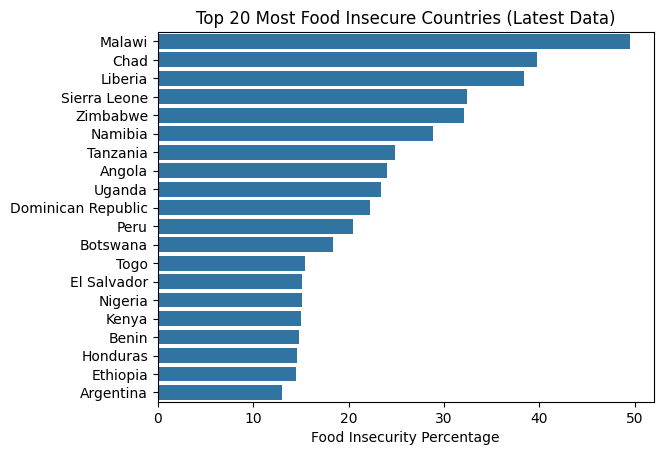

In [ ]:
#visualising the top 20 most food insecure countries- notice that these are all poverty-ridden countries
import seaborn as sns
plt.subplot(1, 1, 1)
sns.barplot(x='Food Insecurity Percentage', y='Country Name',
            data=latestdata.nlargest(20, 'Food Insecurity Percentage'))
plt.title("Top 20 Most Food Insecure Countries (Latest Data)")
plt.xlabel("Food Insecurity Percentage")
plt.ylabel("")

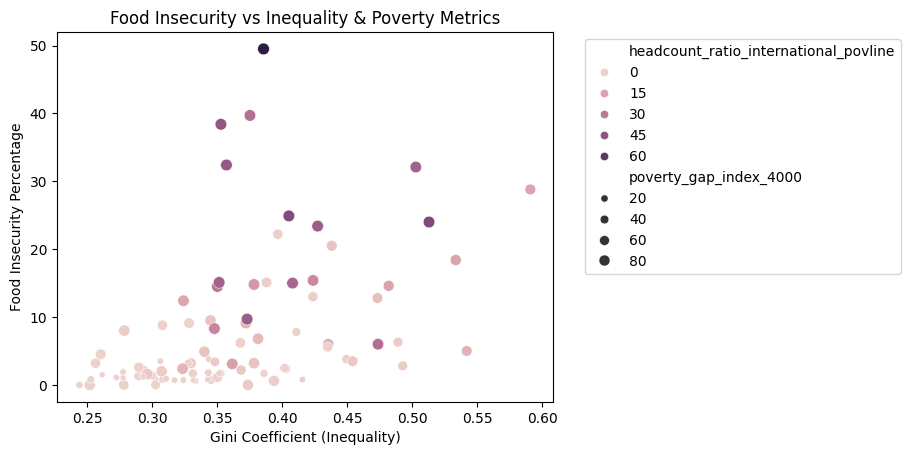

In [ ]:
#visualising food insecurity against poverty metrics-high correlation observed
plt.subplot(1, 1, 1)
sns.scatterplot(x='gini', y='Food Insecurity Percentage',
                hue='headcount_ratio_international_povline',
                size='poverty_gap_index_4000',
                data=latestdata)
plt.title("Food Insecurity vs Inequality & Poverty Metrics")
plt.xlabel("Gini Coefficient (Inequality)")
plt.ylabel("Food Insecurity Percentage")
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')

In [ ]:
#despite the UNs efforts, food insecurity prevalence only grows greater in magnitude
fig = px.choropleth(
    food_insecurity,
    locations="Country Code",
    color="Food Insecurity Percentage",
    hover_name="Country Name",
    animation_frame="year",
    color_continuous_scale="Sunsetdark",
    range_color=(0, 65),
    title="Prevalence of Severe Food Insecurity Over Time"
)

fig.update_layout(
    geo=dict(showframe=False, showcoastlines=False),
    coloraxis_colorbar=dict(title="Food Insecurity (%)")
)

fig.show()

In [ ]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (confusion_matrix, classification_report,
                            accuracy_score, precision_score, recall_score,
                            f1_score, roc_auc_score)
from sklearn.preprocessing import StandardScaler
from imblearn.over_sampling import SMOTE  # For handling class imbalance

In [ ]:
# Load and prepare data
df = pd.read_csv("/content/drive/MyDrive/merged_data.csv")
df_trend = df[['Country Name', 'Years', 'Food Insecurity Percentage']].dropna()

In [ ]:
#sorting countries into super insecure, insecure, or not food insecure
insecurity_level = []
for percent in food_insecurity['Food Insecurity Percentage']:
  if percent >= 15:
    insecurity_level.append('Super Insecure')
  elif percent >= 10:
    insecurity_level.append('Insecure')
  else:
    insecurity_level.append('Not Insecure')

food_insecurity['Insecurity Level'] = insecurity_level
le = LabelEncoder()
y_encoded = le.fit_transform(insecurity_level)
food_insecurity['Insecurity Level'] = y_encoded


In [ ]:
#determines the slope of the food insecurity trend
def compute_trend(group):
    if len(group) >= 2:
        x = group['Years'].values
        y = group['Food Insecurity Percentage'].values
        x_mean = np.mean(x)
        y_mean = np.mean(y)
        numerator = np.sum((x - x_mean) * (y - y_mean))
        denominator = np.sum((x - x_mean) ** 2)
        if denominator == 0:
            return np.nan
        slope = numerator / denominator
        return slope
    return np.nan


#applying our trend function to our dataset
country_trends = df_trend.groupby('Country Name').apply(compute_trend).dropna()
country_trends = country_trends.rename("food_insecurity_trend").reset_index()
country_trends['worsening'] = (country_trends['food_insecurity_trend'] > 0).astype(int)


latest_data = df.sort_values(['Country Name', 'Years'], ascending=[True, False])
latest_data = latest_data.drop_duplicates('Country Name')
classified_data = latest_data.merge(country_trends, on='Country Name')
classified_data.head()

/tmp/ipython-input-2013261473.py:18: DeprecationWarning:

DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.



,Country Name,Country Code,Indicator Name,Indicator Code,Years,Food Insecurity Percentage,reporting_level,welfare_type,ppp_version,survey_year,...,gini,mld,polarization,palma_ratio,s80_s20_ratio,p90_p10_ratio,p90_p50_ratio,p50_p10_ratio,food_insecurity_trend,worsening
0,Albania,ALB,Prevalence of severe food insecurity in the po...,SN.ITK.SVFI.ZS,2019,8.8,national,consumption,2011,2019.0,...,0.307717,0.154626,0.274892,1.132010,4.744671,4.141561,2.105166,1.967332,-0.283333,0
1,Argentina,ARG,Prevalence of severe food insecurity in the po...,SN.ITK.SVFI.ZS,2020,13.0,urban,income,2011,2020.0,...,0.423433,0.319893,0.411175,2.113704,9.821275,8.129676,2.676519,3.037406,1.020000,1
2,Armenia,ARM,Prevalence of severe food insecurity in the po...,SN.ITK.SVFI.ZS,2020,0.0,national,consumption,2011,2020.0,...,0.251717,0.104231,0.201860,0.875969,3.480947,2.928775,1.772414,1.652422,-0.390000,0
3,Australia,AUS,Prevalence of severe food insecurity in the po...,SN.ITK.SVFI.ZS,2018,3.8,national,income,2011,2018.0,...,0.343338,0.225616,0.285311,1.369360,5.746292,4.547085,2.136986,2.127803,0.200000,1
4,Austria,AUT,Prevalence of severe food insecurity in the po...,SN.ITK.SVFI.ZS,2019,0.9,national,income,2011,2019.0,...,0.302116,0.182870,0.254921,1.096517,4.840610,3.918059,1.933268,2.026651,-0.050000,0


In [ ]:
# Enhanced feature selection- choosing core economic indicators and additional predictions
features = ['headcount_ratio_international_povline','income_gap_ratio_international_povline','poverty_gap_index_4000',
     'gini',                      # Inequality measure
    'mean', 'median',            # Central tendency
    'palma_ratio',               # Rich-poor disparity
    'p90_p10_ratio',             # Income inequality
    'decile10_share',            # Top 10% share
    'decile1_share',             # Bottom 10% share

    # Food insecurity measures
    'Food Insecurity Percentage',

    # Poverty measures at different thresholds
    'headcount_ratio_100', 'headcount_ratio_1000'
]

target = 'worsening'

In [ ]:
# Prepare data
X = classified_data[features].copy()
y = classified_data[target]

# Handle missing values - impute with median instead of dropping
for col in X.columns:
    if X[col].isnull().sum() > 0:
        X[col].fillna(X[col].median(), inplace=True)


/tmp/ipython-input-1102096649.py:8: FutureWarning:

A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.





In [ ]:
# Standardize features
scaler = StandardScaler()
X_scaled = pd.DataFrame(scaler.fit_transform(X), columns=X.columns)

# Handle class imbalance using SMOTE
smote = SMOTE(random_state=42)
X_res, y_res = smote.fit_resample(X_scaled, y)


In [ ]:
# Split data
X_train, X_test, y_train, y_test = train_test_split(
    X_res, y_res, test_size=0.2, stratify=y_res, random_state=42
)
#changing the datatype
X_train = X_train.astype(np.float32)
y_train = y_train.astype(np.int32)

# Optimized Random Forest with hyperparameter tuning
param_grid = {
    'n_estimators': [100, 200],
    'max_depth': [3, 5, 7],
    'min_samples_split': [5, 10],
    'class_weight': ['balanced', None]
}
# Hyperparameter tuning using Gridsearchcv -Optimizing for F1 score (balance of precision/recall)
clf = GridSearchCV(
    RandomForestClassifier(random_state=42),
    param_grid,
    cv=5,
    scoring='f1',
    n_jobs=-1
)


In [ ]:
#training the model
clf.fit(X_train, y_train)

# Best model
best_clf = clf.best_estimator_

In [ ]:
#evaluating the model

# Predictions
y_pred = best_clf.predict(X_test)
y_proba = best_clf.predict_proba(X_test)[:, 1]  # Probabilities for AUC

#Comprehensive evaluation
print("Best Parameters:", clf.best_params_)
print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred))

# Additional metrics
print("\nAccuracy:", accuracy_score(y_test, y_pred))
print("Precision:", precision_score(y_test, y_pred))
print("Recall:", recall_score(y_test, y_pred))
print("F1 Score:", f1_score(y_test, y_pred))
print("ROC AUC Score:", roc_auc_score(y_test, y_proba))

# Feature importance
feature_importance = pd.DataFrame({
    'Feature': features,
    'Importance': best_clf.feature_importances_
}).sort_values('Importance', ascending=False)

print("\nTop 10 Features:")
print(feature_importance.head(10))

Best Parameters: {'class_weight': 'balanced', 'max_depth': 5, 'min_samples_split': 5, 'n_estimators': 200}

Confusion Matrix:
 [[6 1]
 [4 3]]

Classification Report:
               precision    recall  f1-score   support

           0       0.60      0.86      0.71         7
           1       0.75      0.43      0.55         7

    accuracy                           0.64        14
   macro avg       0.68      0.64      0.63        14
weighted avg       0.67      0.64      0.63        14


Accuracy: 0.6428571428571429
Precision: 0.75
Recall: 0.42857142857142855
F1 Score: 0.5454545454545454
ROC AUC Score: 0.7551020408163265

Top 10 Features:
                                   Feature  Importance
8                           decile10_share    0.154452
6                              palma_ratio    0.126622
7                            p90_p10_ratio    0.106956
3                                     gini    0.095180
10              Food Insecurity Percentage    0.093641
9                    